In [10]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
tours= pd.read_excel("../data/clean data/df_tours_cleaned.xlsx")

# Afficher un aperçu
tours.head()


,Year,Start_Date,End_Date,Distance(km),Total stages,Total starters,Total Finishers
0,1903,1903-07-01,1903-07-19,2428,6,60,21
1,1904,1904-07-02,1904-07-24,2428,6,88,15
2,1905,1905-07-09,1905-07-30,2994,11,60,24
3,1906,1906-07-04,1906-07-29,4637,13,82,14
4,1907,1907-07-08,1907-08-04,4488,14,93,33


In [11]:
# Sélectionner les colonnes pertinentes
features = tours[['Distance(km)', 'Total stages', 'Total starters', 'Total Finishers']].copy()

# Gérer les valeurs manquantes
features = features.dropna()
[['Distance(km)', 'Total stages', 'Total_ tarters', 'Total Finishers']].copy()

# Gérer les valeurs manquantes
features = features.dropna()


In [12]:

# Créer le modèle
model = IsolationForest(contamination=0.05, random_state=42)

# Entraîner
model.fit(features)

# Prédire les anomalies
tours['Anomaly'] = model.predict(features)


In [13]:
tours['Anomaly_label'] = tours['Anomaly'].apply(lambda x: 'Anomalie' if x == -1 else 'Normale')


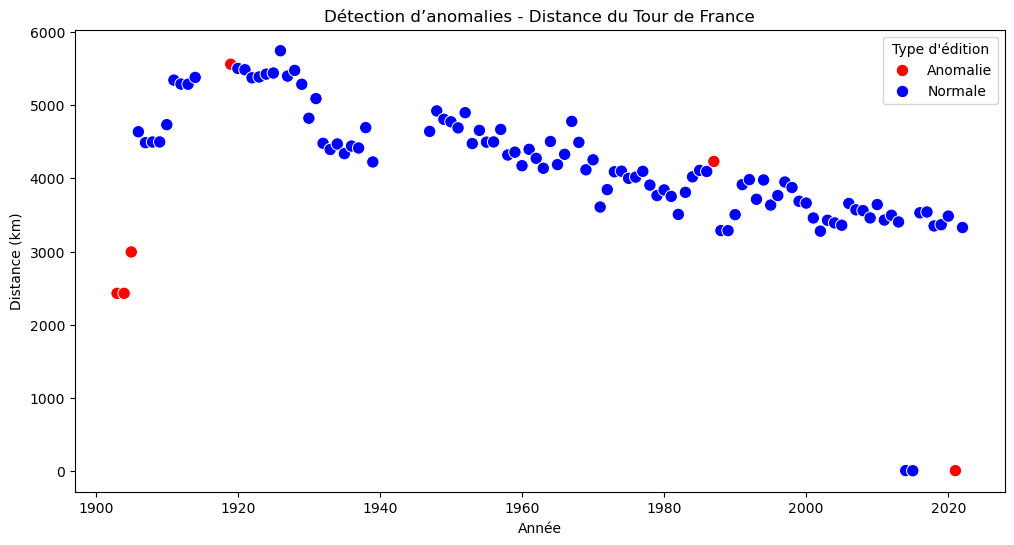

In [14]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=tours, x='Year', y='Distance(km)', hue='Anomaly_label',
                palette={'Normale':'blue', 'Anomalie':'red'}, s=80)
plt.title("Détection d’anomalies - Distance du Tour de France")
plt.xlabel("Année")
plt.ylabel("Distance (km)")
plt.legend(title="Type d'édition")
plt.show()

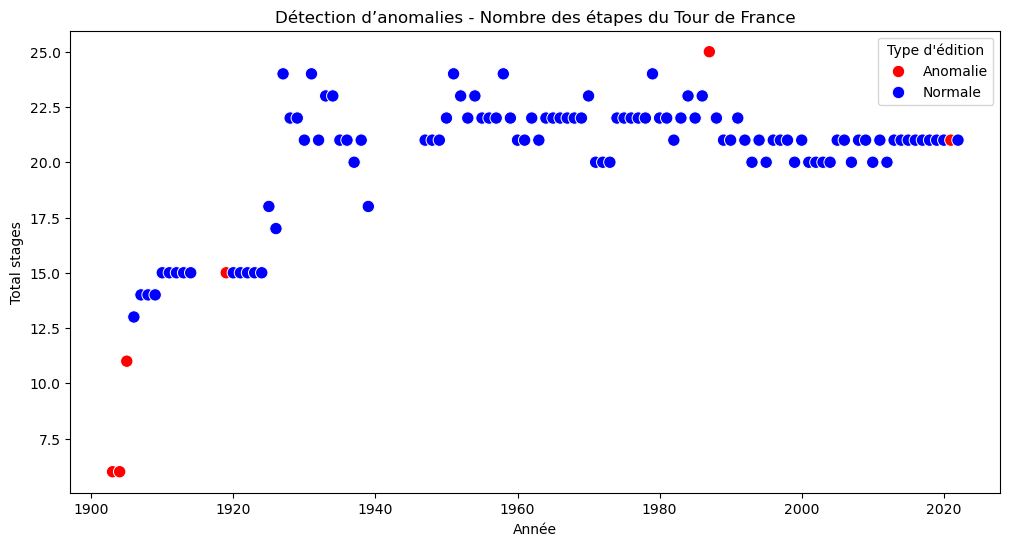

In [15]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=tours, x='Year', y='Total stages', hue='Anomaly_label',
                palette={'Normale':'blue', 'Anomalie':'red'}, s=80)
plt.title("Détection d’anomalies - Nombre des étapes du Tour de France")
plt.xlabel("Année")
plt.ylabel("Total stages")
plt.legend(title="Type d'édition")
plt.show()

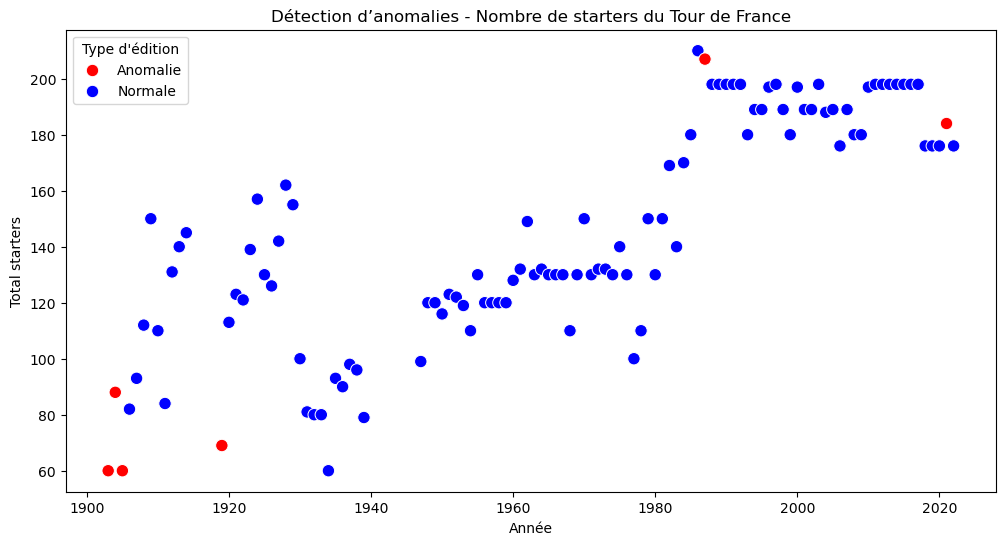

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=tours, x='Year', y='Total starters', hue='Anomaly_label',
                palette={'Normale':'blue', 'Anomalie':'red'}, s=80)
plt.title("Détection d’anomalies - Nombre de starters du Tour de France")
plt.xlabel("Année")
plt.ylabel("Total starters")
plt.legend(title="Type d'édition")
plt.show()

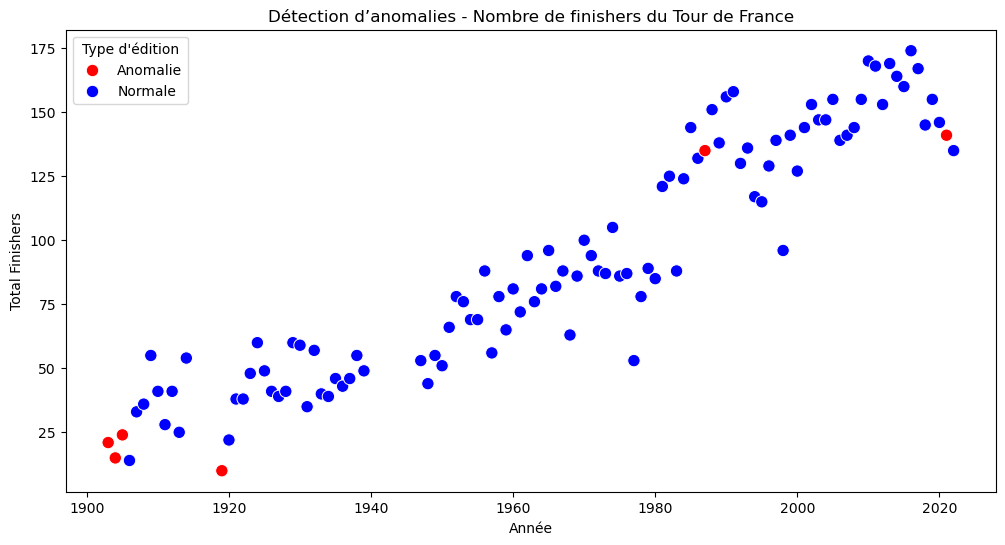

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=tours, x='Year', y='Total Finishers', hue='Anomaly_label',
                palette={'Normale':'blue', 'Anomalie':'red'}, s=80)
plt.title("Détection d’anomalies - Nombre de finishers du Tour de France")
plt.xlabel("Année")
plt.ylabel("Total Finishers")
plt.legend(title="Type d'édition")
plt.show()

In [18]:
export_cols = ['Year', 'Distance(km)', 'Total stages', 'Total starters', 'Total Finishers', 'Anomaly_label']
tours[export_cols].to_excel("../data/results ML/tdf_anomalies_result.xlsx", index=False)

print("✅ Fichier exporté : tdf_anomalies_result.xlsx")
print("Aperçu du résultat :")
print(tours.head())

✅ Fichier exporté : tdf_anomalies_result.xlsx
Aperçu du résultat :
   Year Start_Date   End_Date  Distance(km)  Total stages  Total starters  \
0  1903 1903-07-01 1903-07-19          2428             6              60   
1  1904 1904-07-02 1904-07-24          2428             6              88   
2  1905 1905-07-09 1905-07-30          2994            11              60   
3  1906 1906-07-04 1906-07-29          4637            13              82   
4  1907 1907-07-08 1907-08-04          4488            14              93   

   Total Finishers  Anomaly Anomaly_label  
0               21       -1      Anomalie  
1               15       -1      Anomalie  
2               24       -1      Anomalie  
3               14        1       Normale  
4               33        1       Normale  
